In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [2]:
df = pd.read_csv("injury_data.csv")

print(df.head())
print(df.info())
print(df.describe())

   Player_Age  Player_Weight  Player_Height  Previous_Injuries  \
0          24      66.251933     175.732429                  1   
1          37      70.996271     174.581650                  0   
2          32      80.093781     186.329618                  0   
3          28      87.473271     175.504240                  1   
4          25      84.659220     190.175012                  0   

   Training_Intensity  Recovery_Time  Likelihood_of_Injury  
0            0.457929              5                     0  
1            0.226522              6                     1  
2            0.613970              2                     1  
3            0.252858              4                     1  
4            0.577632              1                     1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Player_Age            100

In [3]:
# Check missing values
print(df.isnull().sum())

# Features and target
X = df.drop("Likelihood_of_Injury", axis=1)
y = df["Likelihood_of_Injury"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (important for SVM & KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Player_Age              0
Player_Weight           0
Player_Height           0
Previous_Injuries       0
Training_Intensity      0
Recovery_Time           0
Likelihood_of_Injury    0
dtype: int64


In [4]:
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

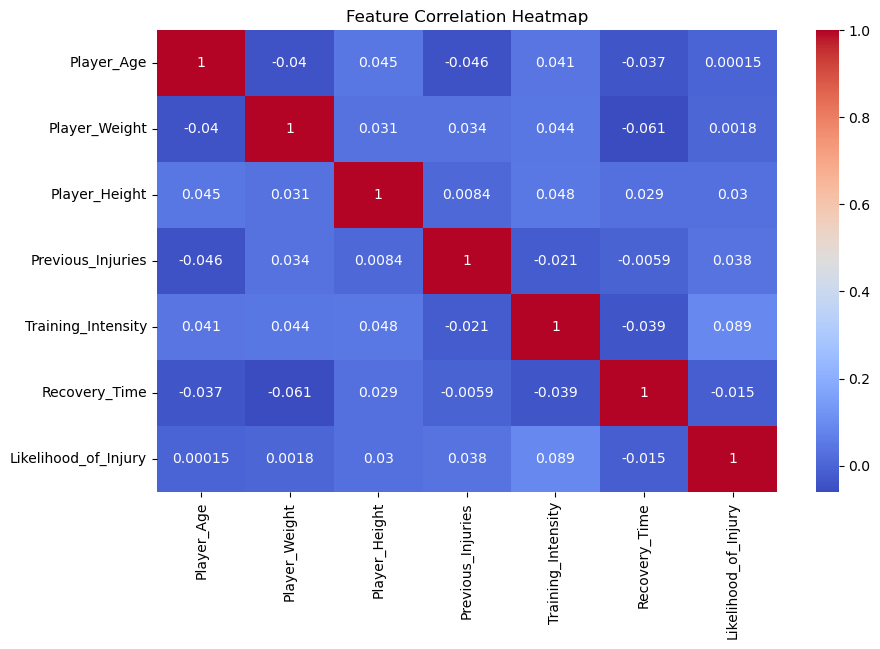

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


Decision Tree Performance:
Accuracy: 0.54
Precision: 0.5384615384615384
Recall: 0.56
F1 Score: 0.5490196078431373


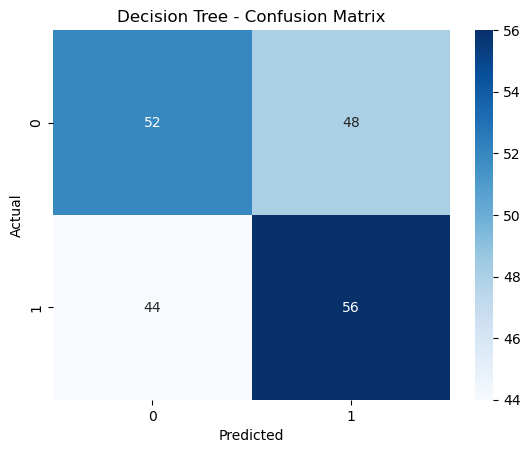

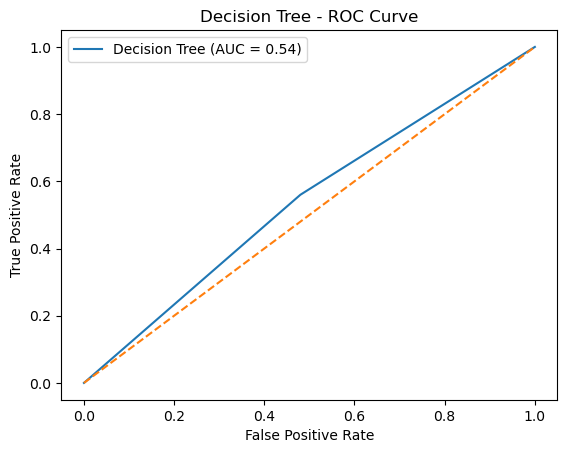


Random Forest Performance:
Accuracy: 0.535
Precision: 0.5327102803738317
Recall: 0.57
F1 Score: 0.5507246376811594


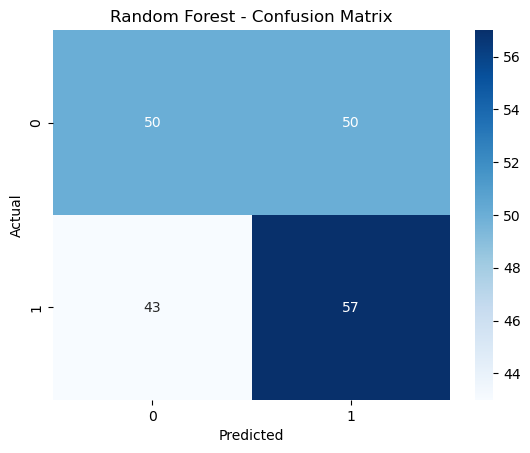

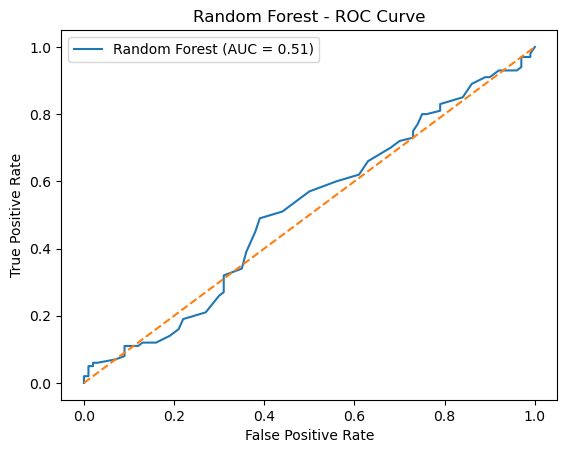


SVM Performance:
Accuracy: 0.53
Precision: 0.5254237288135594
Recall: 0.62
F1 Score: 0.5688073394495413


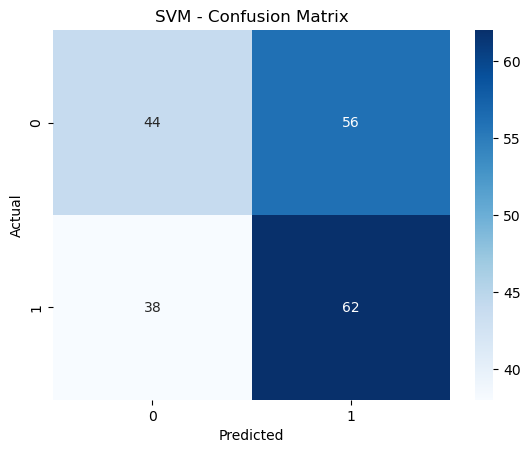

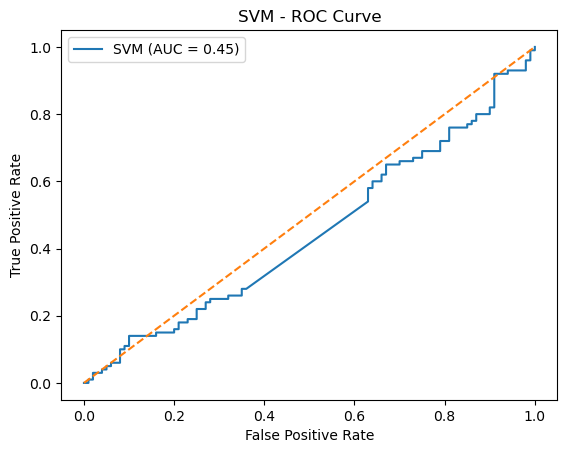


KNN Performance:
Accuracy: 0.585
Precision: 0.5825242718446602
Recall: 0.6
F1 Score: 0.5911330049261084


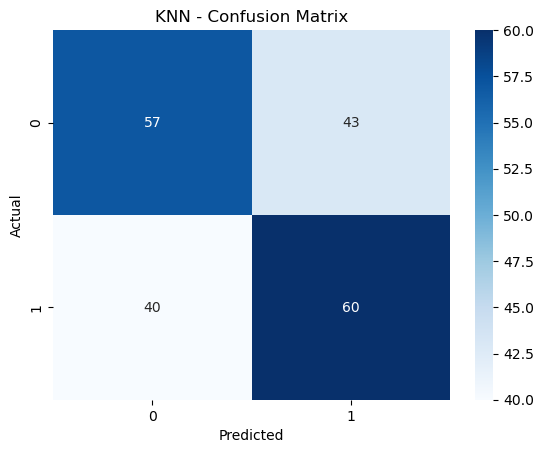

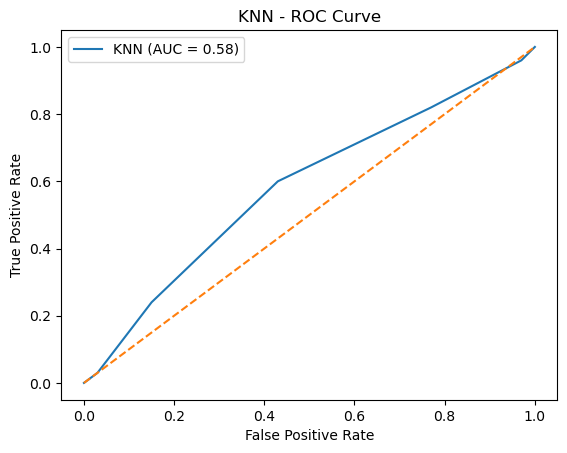

In [8]:
evaluate_model(dt, X_test, y_test, "Decision Tree")
evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(svm, X_test_scaled, y_test, "SVM")
evaluate_model(knn, X_test_scaled, y_test, "KNN")

In [9]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn
}

for name, model in models.items():
    if name in ["SVM", "KNN"]:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5)

    print(f"{name} CV Accuracy: {scores.mean():.4f}")

Decision Tree CV Accuracy: 0.4900
Random Forest CV Accuracy: 0.4913
SVM CV Accuracy: 0.4738
KNN CV Accuracy: 0.5037


In [10]:
ensemble = VotingClassifier(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('svm', svm)
    ],
    voting='soft'
)

ensemble.fit(X_train_scaled, y_train)

y_pred = ensemble.predict(X_test_scaled)

print("\nEnsemble Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Ensemble Model Performance:
Accuracy: 0.54
Precision: 0.5384615384615384
Recall: 0.56
F1 Score: 0.5490196078431373


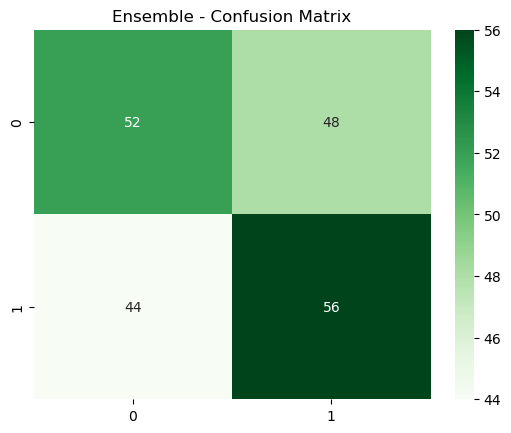

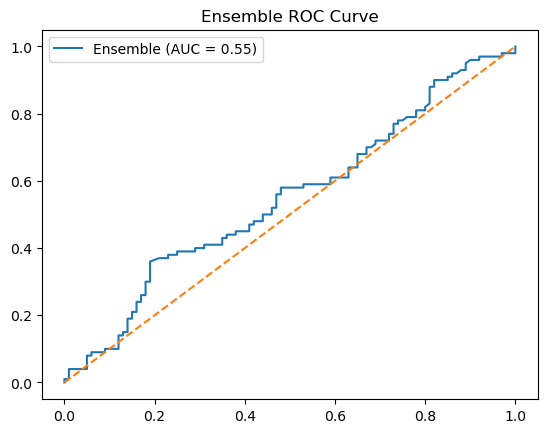

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Ensemble - Confusion Matrix")
plt.show()

# ROC (use probabilities)
ensemble_soft = VotingClassifier(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('svm', svm)
    ],
    voting='soft'
)

ensemble_soft.fit(X_train_scaled, y_train)
y_prob = ensemble_soft.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Ensemble (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend()
plt.title("Ensemble ROC Curve")
plt.show()